# Phase 6: Model Evaluation and Selection
In this notebook, we load the trained models from Phase 5 and evaluate them on unseen testing data. We generate classification reports, confusion matrices, and cross-validation scores to confidently select the most robust model for deployment.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

plt.style.use('ggplot')

## 1. Load Models & Data
We load the serialized TF-IDF testing sparse matrices, the target arrays, the `LabelEncoder`, and our three predictive models.

In [2]:
X_train = joblib.load('../models/X_train.pkl')
y_train = joblib.load('../models/y_train.pkl')
X_test = joblib.load('../models/X_test.pkl')
y_test = joblib.load('../models/y_test.pkl')
label_encoder = joblib.load('../models/label_encoder.pkl')

dt_model = joblib.load('../models/decision_tree_model.pkl')
knn_model = joblib.load('../models/knn_model.pkl')
svm_model = joblib.load('../models/svm_model.pkl')

class_names = label_encoder.classes_

models = {
    'Decision Tree': dt_model,
    'KNN': knn_model,
    'SVM': svm_model
}

print("All models and data loaded successfully.")

All models and data loaded successfully.


## 2. Evaluate Models (Predictions & Metrics)
Iterating through each model to generate predictions on `X_test`. We extract Accuracy, Precision, Recall, and F1-Scores.

In [3]:
metrics_data = []

for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Evaluating: {name}")
    print(f"{'='*40}")
    
    # Generate Predictions
    preds = model.predict(X_test)
    
    # Evaluation Metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test, preds, average='weighted', zero_division=0)
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, preds, target_names=class_names, zero_division=0))
    
    # Cross Validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    cv_mean = cv_scores.mean()
    print(f"5-Fold CV Mean Accuracy: {cv_mean:.4f} (+/- {cv_scores.std():.4f})")
    
    metrics_data.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'Cross Validation Mean': cv_mean
    })


Evaluating: Decision Tree

Classification Report:
                           precision    recall  f1-score   support

         Business Analyst       0.00      0.00      0.00         1
           Cloud Engineer       1.00      1.00      1.00         6
   Cyber Security Analyst       1.00      1.00      1.00         1
            Data Engineer       1.00      0.50      0.67         2
           Data Scientist       0.86      0.75      0.80         8
   Database Administrator       1.00      1.00      1.00         2
Machine Learning Engineer       0.67      0.50      0.57         4
       Software Developer       0.86      0.98      0.91        43
            Web Developer       1.00      0.88      0.93        16

                 accuracy                           0.89        83
                macro avg       0.82      0.73      0.76        83
             weighted avg       0.88      0.89      0.88        83



C:\Users\RITHVIK\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


5-Fold CV Mean Accuracy: 0.8606 (+/- 0.0294)

Evaluating: KNN

Classification Report:
                           precision    recall  f1-score   support

         Business Analyst       0.00      0.00      0.00         1
           Cloud Engineer       1.00      0.83      0.91         6
   Cyber Security Analyst       0.00      0.00      0.00         1
            Data Engineer       1.00      1.00      1.00         2
           Data Scientist       0.86      0.75      0.80         8
   Database Administrator       1.00      1.00      1.00         2
Machine Learning Engineer       0.80      1.00      0.89         4
       Software Developer       0.91      1.00      0.96        43
            Web Developer       1.00      0.94      0.97        16

                 accuracy                           0.93        83
                macro avg       0.73      0.72      0.72        83
             weighted avg       0.91      0.93      0.92        83



C:\Users\RITHVIK\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


5-Fold CV Mean Accuracy: 0.9242 (+/- 0.0096)

Evaluating: SVM

Classification Report:
                           precision    recall  f1-score   support

         Business Analyst       0.00      0.00      0.00         1
           Cloud Engineer       1.00      0.83      0.91         6
   Cyber Security Analyst       0.00      0.00      0.00         1
            Data Engineer       1.00      1.00      1.00         2
           Data Scientist       1.00      0.88      0.93         8
   Database Administrator       1.00      0.50      0.67         2
Machine Learning Engineer       1.00      1.00      1.00         4
       Software Developer       0.86      1.00      0.92        43
            Web Developer       1.00      0.88      0.93        16

                 accuracy                           0.92        83
                macro avg       0.76      0.68      0.71        83
             weighted avg       0.90      0.92      0.90        83



C:\Users\RITHVIK\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


5-Fold CV Mean Accuracy: 0.9121 (+/- 0.0201)


## 3. Model Comparison Table
Consolidating all extracted metrics into a single Pandas DataFrame.

In [4]:
df_metrics = pd.DataFrame(metrics_data)
print("=== Model Comparison Table ===")
display(df_metrics)

=== Model Comparison Table ===


,Model,Accuracy,Precision,Recall,F1,Cross Validation Mean
0,Decision Tree,0.891566,0.884108,0.891566,0.882087,0.860606
1,KNN,0.927711,0.908404,0.927711,0.915456,0.924242
2,SVM,0.915663,0.903373,0.915663,0.903028,0.912121


## 4. Visualizing Performance
Plotting bar charts to compare Accuracy, Precision, Recall, F1, and Cross Validation Mean across our algorithms.

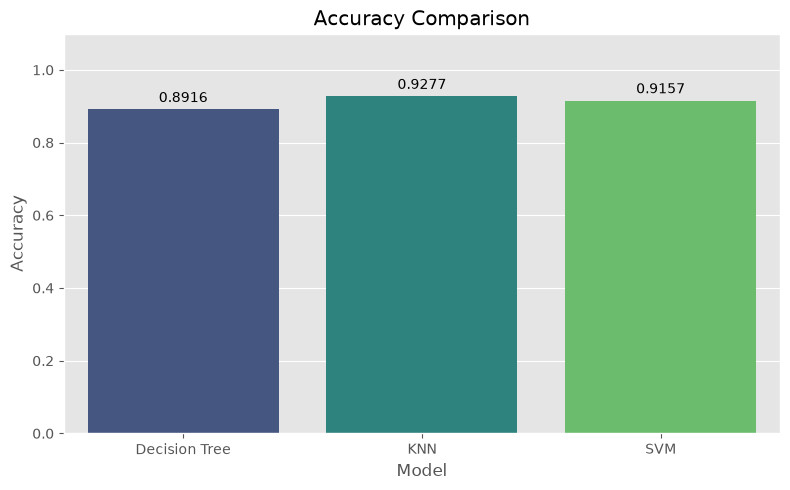

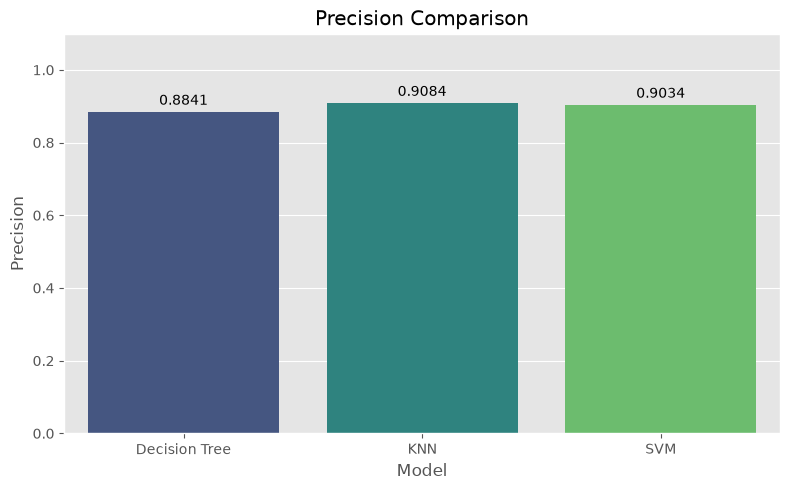

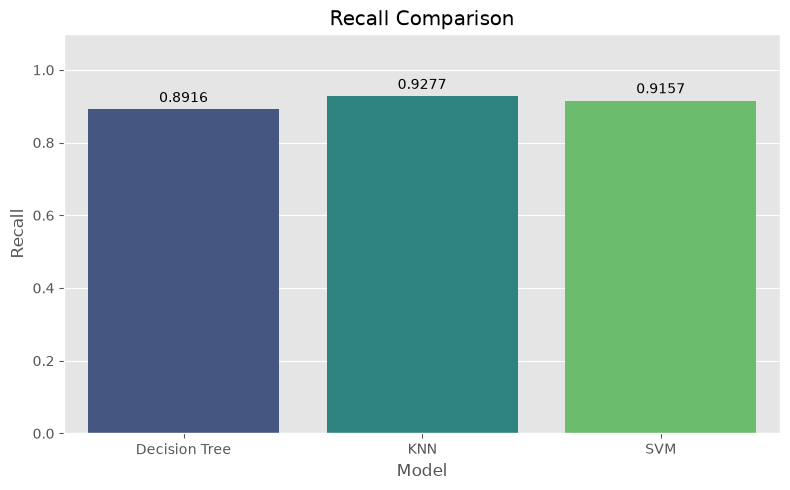

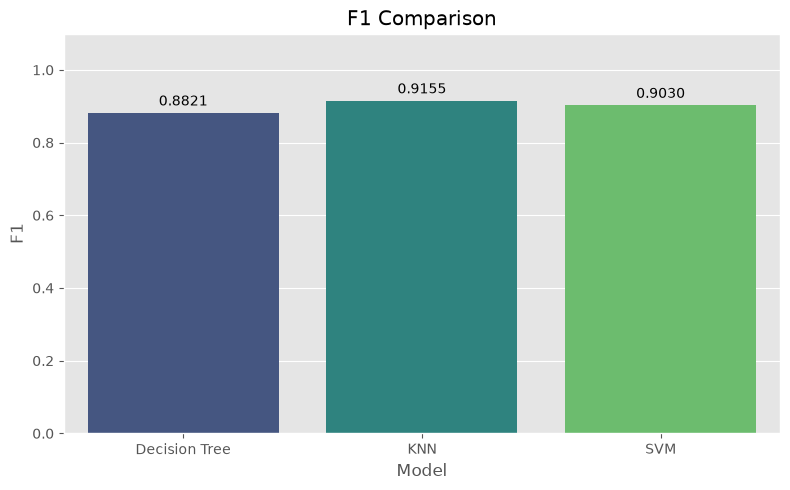

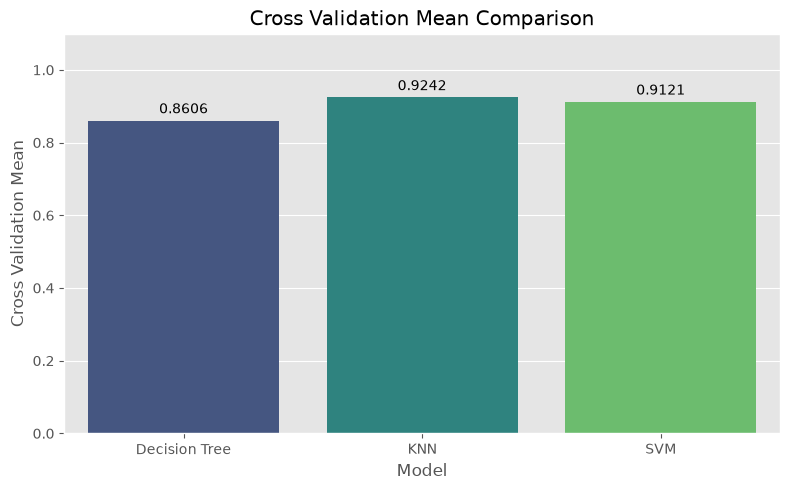

In [5]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'Cross Validation Mean']

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x='Model', y=metric, data=df_metrics, hue='Model', palette='viridis', legend=False)
    plt.title(f'{metric} Comparison')
    plt.ylim(0, 1.1)
    for i, v in enumerate(df_metrics[metric]):
        plt.text(i, v + 0.02, f"{v:.4f}", ha='center')
    plt.tight_layout()
    plt.show()

## 5. Model Selection & Final Output
Automatically computing the best model based on weighted F1 score and Cross-Validation stability. The best model will be persisted as `models/career_model.pkl` for production use.

In [6]:
# Determine the best model automatically
best_model_row = df_metrics.sort_values(by=['Cross Validation Mean', 'Accuracy', 'F1'], ascending=[False, False, False]).iloc[0]
best_model_name = best_model_row['Model']

print(f"Best Model Selected: {best_model_name}")

if best_model_name == 'Decision Tree':
    shutil.copy('../models/decision_tree_model.pkl', '../models/career_model.pkl')
elif best_model_name == 'KNN':
    shutil.copy('../models/knn_model.pkl', '../models/career_model.pkl')
else:
    shutil.copy('../models/svm_model.pkl', '../models/career_model.pkl')

print(f"Verified models/career_model.pkl exists: {os.path.exists('../models/career_model.pkl')}")

Best Model Selected: KNN
Verified models/career_model.pkl exists: True
